# **Clustering of Side Effects**


# Import Libraries

In [1]:
%matplotlib inline

import re

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer, util
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

/home/mylena-roberta/Unicamp/MO412/medications-and-side-effects-networks/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Model Steps

## Load Data and Generate Embeddings

In [2]:
# Create a DataFrame for the side effects
df_nodes = pd.read_csv('../data/processed/bipartite-network-nodes.csv')
df_effects = (
    df_nodes.query('type == "side effect"')
    .reset_index(drop=True)[['id']]
)

# Use a modern biomedical embedding model
model = SentenceTransformer('NeuML/pubmedbert-base-embeddings')

# Normalize embeddings to unit length (for cosine similarity)
embeddings = model.encode(
    df_effects['id'],
    show_progress_bar=True,
    normalize_embeddings=True
)

Batches: 100%|██████████| 5/5 [00:01<00:00,  4.55it/s]


## Cluster Side Effects

In [3]:
# Find best number of clusters using silhouette score
sil_scores = {}
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(embeddings)
    sil = silhouette_score(embeddings, labels)
    sil_scores[k] = sil

best_k = max(sil_scores, key=sil_scores.get)
print(f'Optimal number of clusters: {best_k} (silhouette={sil_scores[best_k]:.3f})')

# Fit final model
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_effects['cluster'] = kmeans.fit_predict(embeddings)

Optimal number of clusters: 9 (silhouette=0.066)


## Severity Anchors

In [4]:
anchor_texts = {
    'mild': [
        'temporary tiredness', 'slight dryness', 'minor discomfort',
        'temporary drowsiness', 'mild headache', 'light dizziness',
        'slight itching', 'mild irritation', 'minor nausea'
    ],
    'moderate': [
        'vomiting', 'moderate rash', 'abdominal pain',
        'painful swelling', 'short-term confusion', 'moderate dizziness',
        'persistent cough', 'joint pain'
    ],
    'severe': [
        'seizure', 'organ failure', 'cardiac arrest',
        'respiratory depression', 'coma', 'loss of consciousness',
        'anaphylaxis', 'stroke', 'life-threatening reaction'
    ],
}

# Mean embedding for each severity level
anchors = {
    k: np.mean(model.encode(v, normalize_embeddings=True), axis=0)
    for k, v in anchor_texts.items()
}

def compute_severity_score(effect):
    emb = model.encode(effect, normalize_embeddings=True)
    sims = np.array([util.cos_sim(emb, anchors[label]).item()
                     for label in ['mild', 'moderate', 'severe']])
    probs = np.exp(sims) / np.sum(np.exp(sims)) # Softmax weighting
    # Balanced continuous score: 0 = mild, 1 = severe
    return probs[2] * 1.0 + probs[1] * 0.5 + probs[0] * 0.0

df_effects['severity_score'] = df_effects['id'].apply(compute_severity_score)

## Domain Adjustment with Exceptions

In [5]:
# Core biomedical and cosmetic terms
critical_terms = [
    'cardiac', 'heart', 'respiratory', 'breath', 'seizure',
    'coma', 'renal', 'hepatic', 'neurologic', 'stroke', 'shock', 'collapse'
]
minor_terms = [
    'rash', 'itch', 'taste', 'weight', 'appetite', 'sleep',
    'fatigue', 'dry skin', 'hair', 'vision', 'mouth', 'mild'
]

# Exception lists for over- or under-classified terms
overrated_terms = [
    'heartburn', 'indigestion', 'constipation', 'diarrhea',
    'dry mouth', 'sweating', 'runny nose', 'mild pain'
]
emotional_terms = [
    'depression', 'anxiety', 'insomnia', 'stress', 'mood swing',
    'irritability', 'emotional', 'confusion'
]

def adjust_by_system(effect, score):
    text = effect.lower()

    # Explicit exceptions first
    if any(re.search(rf'\b{term}\b', text) for term in overrated_terms):
        # Never classify as severe
        return min(score, 0.55)

    if any(re.search(rf'\b{term}\b', text) for term in emotional_terms):
        # Psychological symptoms are usually moderate
        score -= 0.1
        return max(score, 0.2)

    # Normal biomedical adjustments
    if any(re.search(rf'\b{term}\b', text) for term in critical_terms):
        score += 0.2
    elif any(re.search(rf'\b{term}\b', text) for term in minor_terms):
        score -= 0.15
        score = min(score, 0.65) # Cap: mild/moderate only

    return min(max(score, 0), 1)

df_effects['severity_score'] = df_effects.apply(
    lambda x: adjust_by_system(x['id'], x['severity_score']),
    axis=1
)

## Normalize & Asymmetric Calibration

In [6]:
# Normalize to [0,1]
df_effects['severity_score'] = (
    df_effects['severity_score'] - df_effects['severity_score'].min()
) / (
    df_effects['severity_score'].max() - df_effects['severity_score'].min()
)

# Asymmetric cutoffs: make severe rarer
q_mild = df_effects['severity_score'].quantile(0.45)
q_moderate = df_effects['severity_score'].quantile(0.85)

def assign_severity(score):
    if score <= q_mild:
        return 'mild'
    elif score <= q_moderate:
        return 'moderate'
    else:
        return 'severe'

df_effects['severity'] = df_effects['severity_score'].apply(assign_severity)

## Manual Rebalancing of Edge Cases

In [7]:
def manual_rebalance(effect, severity, score):
    text = str(effect).lower().strip()
    text = re.sub(r'[\s\-]+', ' ', text)

    # Mild/moderate gastrointestinal or common side effects
    if any(term in text for term in ['heartburn', 'indigestion', 'constipation', 'dyspepsia']):
        return 'moderate' if score > 0.35 else 'mild'

    # Psychological effects (usually moderate)
    if any(term in text for term in ['depression', 'anxiety', 'insomnia', 'stress']):
        return 'moderate'

    # Critical/life-threatening terms → severe
    critical_terms = [
        'respiratory depression', 'respiratory failure', 'respiratory arrest',
        'cardiac arrest', 'heart failure', 'shock', 'coma', 'seizure',
        'apnea', 'circulatory collapse', 'cardiac disorder'
    ]
    if any(term in text for term in critical_terms):
        return 'severe'

    return severity

df_effects['severity'] = df_effects.apply(
    lambda x: manual_rebalance(x['id'], x['severity'], x['severity_score']),
    axis=1
)

# Model Results

## Distribution of Severities

severity
moderate    44.7%
mild        40.9%
severe      14.4%
Name: proportion, dtype: object


/tmp/ipykernel_29427/2313523714.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


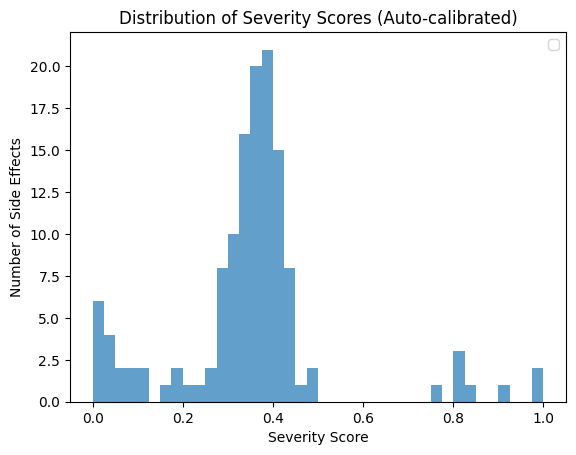

In [8]:
# Compute the proportion of side effects by each severity level
print(
    df_effects['severity'] \
        .value_counts(normalize=True) \
        .apply(lambda x: f'{x:.1%}')
)

# Histogram of severity scores
plt.hist(df_effects['severity_score'], bins=40, alpha=0.7)

# Plot configurations
plt.title('Distribution of Severity Scores (Auto-calibrated)')
plt.xlabel('Severity Score')
plt.ylabel('Number of Side Effects')
plt.legend()
plt.show()

## Severe Side Effects

In [9]:
df_effects.query('severity == "severe"') \
    .sort_values(by='severity_score') \
    .reset_index(drop=True)

,id,cluster,severity_score,severity
0,impaired coordination,1,0.422026,severe
1,lethargy,8,0.425122,severe
2,aggression,8,0.425812,severe
3,breathlessness,2,0.427006,severe
4,speech disorder,5,0.434357,severe
5,cns stimulation,8,0.435197,severe
6,drug withdrawal syndrome,2,0.440427,severe
7,apnea (absence of breathing),2,0.448210,severe
8,memory impairment,4,0.453308,severe
9,memory loss,4,0.478150,severe


## Moderate Side Effects

In [10]:
df_effects.query('severity == "moderate"') \
    .sort_values(by='severity_score') \
    .reset_index(drop=True)

,id,cluster,severity_score,severity
0,anxiety,8,0.159624,moderate
1,insomnia (difficulty in sleeping),8,0.177155,moderate
2,depression,8,0.210719,moderate
3,respiratory depression,2,0.258276,moderate
4,dyspepsia,6,0.350976,moderate
5,difficulty in urination,6,0.355300,moderate
6,orthostatic hypotension (sudden lowering of bl...,2,0.357595,moderate
7,indigestion,8,0.358215,moderate
8,vomiting,6,0.358388,moderate
9,muscle stiffness,1,0.360698,moderate


## Mild Side Effects

In [11]:
df_effects.query('severity == "mild"') \
    .sort_values(by='severity_score') \
    .reset_index(drop=True)

,id,cluster,severity_score,severity
0,skin rash,3,0.000000,mild
1,rash,3,0.006110,mild
2,decreased appetite,6,0.010134,mild
3,metallic taste,5,0.015351,mild
4,bitter taste,5,0.021903,mild
5,numbness in mouth,3,0.022190,mild
6,chalky taste,5,0.038930,mild
7,dryness in mouth,5,0.041959,mild
8,taste change,5,0.043921,mild
9,weight gain,6,0.049578,mild


## Store Side Effects Classification

In [12]:
# Add clustering results as attributes of side effect nodes
df_nodes = pd.merge(left=df_nodes, right=df_effects, how='left', on='id')

# Store the updated CSV file with the node attributes
df_nodes.to_csv('../data/processed/bipartite-network-nodes.csv', sep=';', index=False)

# Print the updated CSV file with the node attributes
df_nodes

,id,uses,chemical_class,habit_forming,therapeutic_class,action_class,label,type,cluster,severity_score,severity
0,a-tryp forte tablet,{'treatment of depression'},{nan},yes,{'neuro cns'},{nan},a-tryp forte tablet,medication,NaN,NaN,NaN
1,aaram 0.5mg tablet,"{'treatment of anxiety', 'treatment of panic d...",{'benzodiazepines derivative'},yes,{'neuro cns'},{'benzodiazepines'},aaram 0.5mg tablet,medication,NaN,NaN,NaN
2,aaram tablet,"{'treatment of anxiety', 'treatment of panic d...",{'benzodiazepines derivative'},yes,{'neuro cns'},{'benzodiazepines'},aaram tablet,medication,NaN,NaN,NaN
3,abdocool tablet,{'treatment of irritable bowel syndrome'},{nan},yes,{'gastro intestinal'},{nan},abdocool tablet,medication,NaN,NaN,NaN
4,abidol 100mg injection,{' moderate to severe pain'},{'anisole derivative'},yes,{'pain analgesics'},{'opioids'},abidol 100mg injection,medication,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
5580,apnea (absence of breathing),NaN,NaN,NaN,NaN,NaN,apnea (absence of breathing),side effect,2.0,0.448210,severe
5581,respiratory arrest,NaN,NaN,NaN,NaN,NaN,respiratory arrest,side effect,2.0,0.992852,severe
5582,circulatory disorder,NaN,NaN,NaN,NaN,NaN,circulatory disorder,side effect,2.0,0.482347,severe
5583,shock,NaN,NaN,NaN,NaN,NaN,shock,side effect,2.0,0.903985,severe
